In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import SEACells 
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad


In [9]:
sc_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/sc_data.h5ad")
st_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/st_data.h5ad")


In [4]:
cell_type_palette = {'Astro': (0.843137, 0.0, 0.0, 1.0),
                     'Endo': (0.54902, 0.235294, 1.0, 1.0),
                     'L23_IT': (0.007843, 0.533333, 0.0, 1.0),
                     'L45_IT': (0.0, 0.67451, 0.780392, 1.0),
                     'L56_NP': (0.596078, 1.0, 0.0, 1.0),
                     'L5_ET': (1.0, 0.498039, 0.819608, 1.0),
                     'L5_IT': (0.423529, 0.0, 0.309804, 1.0),
                     'L5_PT': (1.0, 0.647059, 0.188235, 1.0),
                     'L6_CT': (0.345098, 0.231373, 0.0, 1.0),
                     'L6_IT': (0.0, 0.341176, 0.34902, 1.0),
                     'L6_IT_Car3': (0.0, 0.0, 0.866667, 1.0),
                     'L6b': (0.0, 0.992157, 0.811765, 1.0),
                     'Lamp5': (0.631373, 0.458824, 0.415686, 1.0),
                     'Microglia': (0.737255, 0.717647, 1.0, 1.0),
                     'OPC': (0.584314, 0.709804, 0.470588, 1.0),
                     'Oligo': (0.752941, 0.015686, 0.72549, 1.0),
                     'Pericytes': (0.392157, 0.329412, 0.454902, 1.0),
                     'Pvalb': (0.47451, 0.0, 0.0, 1.0),
                     'SMC': (0.027451, 0.454902, 0.847059, 1.0),
                     'Sncg': (0.996078, 0.960784, 0.564706, 1.0),
                     'Sst': (0.0, 0.294118, 0.0, 1.0),
                     'VLMC': (0.560784, 0.478431, 0.0, 1.0),
                     'Vip': (1.0, 0.447059, 0.4, 1.0)}

cell_label_palette = {'GABAergic': (0.843137, 0.0, 0.0, 1.0),
                      'Glutamatergic': (0.54902, 0.235294, 1.0, 1.0),
                      'Non-Neuronal': (0.007843, 0.533333, 0.0, 1.0)}

In [5]:
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)
print("Shape of combined_cell_types", combined_cell_types.shape)

Shape of combined_cell_types (25932,)


In [10]:
st_ad

AnnData object with n_obs × n_vars = 18516 × 252
    obs: 'fovID', 'fov_x', 'fov_y', 'volume', 'center_x', 'center_y', 'slice_id', 'sample_id', 'label', 'subclass', 'class_label', 'cell_id', 'cell_type', 'batch', 'cell_label'
    var: 'n_iso'
    uns: 'COVET_genes'
    obsm: 'COVET', 'COVET_SQRT', 'cell_type_niche', 'envi_latent', 'imputation', 'spatial'
    layers: 'X', 'log1p', 'norm'

In [11]:
# Flatten the (64, 64) matrices into 1D vectors
st_covet_sqrt_flat = st_ad.obsm["COVET_SQRT"].reshape(st_ad.shape[0], -1)
sc_covet_sqrt_flat = sc_ad.obsm["COVET_SQRT"].reshape(sc_ad.shape[0], -1)

# Combine both datasets for joint UMAP
covet_sqrt_combined = np.concatenate([st_covet_sqrt_flat, sc_covet_sqrt_flat], axis=0)

In [12]:
covet_sqrt_combined

array([[ 7.12395355e-04, -2.61447043e-03,  2.05038174e-04, ...,
         5.53785041e-02, -5.56620918e-02,  1.93564534e-01],
       [ 6.36535464e-04, -4.07962920e-03,  5.45900664e-04, ...,
         2.36149430e-02, -5.49935363e-02,  1.03644766e-01],
       [ 6.32807321e-04,  3.31655890e-03, -4.97922709e-04, ...,
        -8.86420999e-03,  2.05024518e-02,  1.03581749e-01],
       ...,
       [ 3.36207449e-05,  3.28421593e-03, -4.01679426e-05, ...,
         2.64329202e-02,  3.86447981e-02,  4.00460601e-01],
       [ 1.28799677e-03,  1.83649063e-02,  7.27236271e-04, ...,
         1.30811706e-03,  4.86928001e-02,  4.95014012e-01],
       [ 1.64285302e-04, -7.35998154e-03, -1.48639083e-05, ...,
         2.53679454e-02,  4.83936705e-02,  4.05316740e-01]], dtype=float32)

In [13]:
obs = pd.DataFrame(index=[f"cell_{i}" for i in range(covet_sqrt_combined.shape[0])])


In [14]:
adata_combined = ad.AnnData(X=covet_sqrt_combined)
adata_combined.obs["cell_type"] = combined_cell_types
adata_combined.obsm["envi_latent"] = covet_sqrt_combined

print(adata_combined)
print(adata_combined.obs["cell_type"].head())


AnnData object with n_obs × n_vars = 25932 × 4096
    obs: 'cell_type'
    obsm: 'envi_latent'
0     L5_IT
1     L5_IT
2    L56_NP
3     L6_CT
4    L23_IT
Name: cell_type, dtype: object


In [6]:
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)


In [13]:
combined_cell_types.shape

(25932,)

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 4096 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


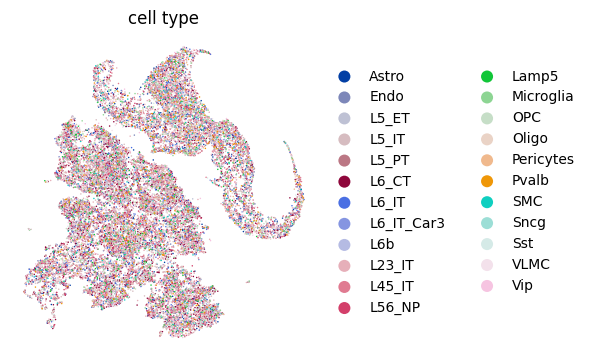

In [15]:
sc.pp.neighbors(adata_combined, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_combined)
sc.pl.scatter(adata_combined, basis='umap', color=['cell_type'], frameon=False)

In [17]:
print(np.isinf(adata_combined.X).sum())

0


In [18]:
raw_ad=sc.AnnData(adata_combined.X)
raw_ad.obs_names, raw_ad.var_names=adata_combined.obs_names, adata_combined.var_names
adata_combined.raw=raw_ad


In [20]:
mask = np.isfinite(adata_combined.X).all(axis=1)
adata_combined = adata_combined[mask, :]
print(f"Filtered cells: {adata_combined.shape[0]}")


Filtered cells: 25932


In [23]:
sc.pp.pca(adata_combined, n_comps=50, use_highly_variable=False)

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


In [24]:
#Construct kernel matrix

n_SEACells=100 
build_kernel_on='X_pca'
n_waypoint_eigs=10

In [25]:
model= SEACells.core.SEACells(adata_combined, 
                              build_kernel_on= build_kernel_on,
                              n_SEACells=n_SEACells,
                              n_waypoint_eigs=n_waypoint_eigs,
                              convergence_epsilon=1e-5
                              )

Welcome to SEACells!


In [26]:
model.construct_kernel_matrix()
M=model.kernel_matrix

Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...


  0%|          | 0/25932 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/25932 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/25932 [00:00<?, ?it/s]

Constructing CSR matrix...


In [27]:
model.initialize_archetypes()

Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 95 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 15/15 [00:00<00:00, 82.19it/s]

Selecting 5 cells from greedy initialization.


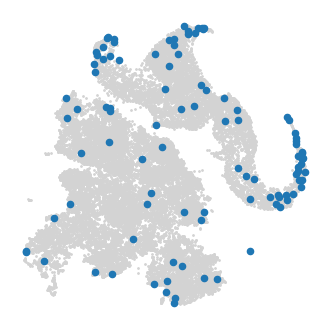

In [28]:
SEACells.plot.plot_initialization(adata_combined, model)

In [29]:
model.fit(min_iter=10, max_iter=30)
print (f'Ran for {len(model.RSS_iters)} iterations')

Randomly initialized A matrix.
Setting convergence threshold at 0.00302
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.


KeyboardInterrupt: 

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/SEACells/plot.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby('SEACell').mean().reset_index()
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


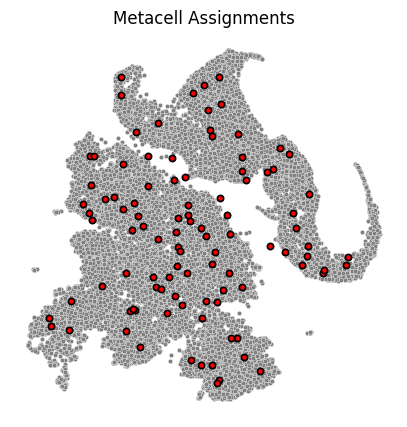

In [30]:
SEACells.plot.plot_2D(adata_combined, colour_metacells=False)

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/SEACells/plot.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby('SEACell').mean().reset_index()
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


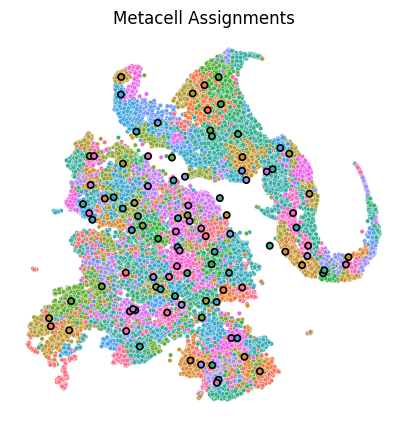

In [31]:
SEACells.plot.plot_2D(adata_combined, colour_metacells=True)

envi and covet separately knn graph using 50 embedding of envi and 50 embedding of covet. combine then using snn.then use seacells. 